In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadMoments import *
from LoadTSV import *

In [2]:
WIDTH = 9.0#!6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [3]:
# Plotting
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 1))]

# Some first plots

In [4]:
# Parameter
M = 4
closure = "ExtGram"
Kn = 1.0
source_string = "relaxation_source"
T_end = 0.3
base_tree_level = 10
polydeg = 1
rho_L = 7.0
v_L1 = 0.0
v_L2 = 0.0
v_L3 = 0.0
theta_L = 1.0
rho_R = 1.0
v_R1 = 0.0
v_R2 = 0.0
v_R3 = 0.0
theta_R = 1.0

In [5]:
closure = 'ExtGram'
Kn = 1.0
T_end = 0.3
n_angle_pairs = 4
name = lambda anglepair: f"../out/1D3D/1D3D_angles/gram_solution_1D3D_closure{closure}_Kn{Kn}_anglepairnumber{anglepair}_Tend{T_end}_cons.tsv"

marker = ['o', 's', '^', 'x', 'd']

In [6]:
Knudsen = [0.1, 1.0, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source']
name = lambda anglepairnumber, Kn, source_string: f"../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_cons.tsv"

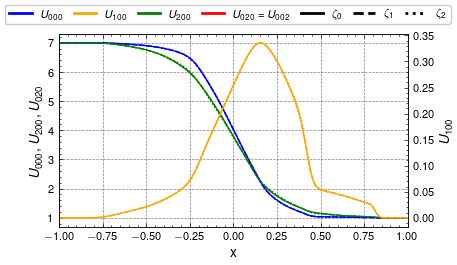

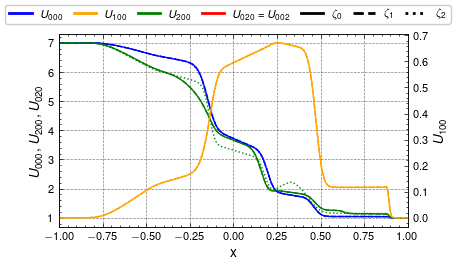

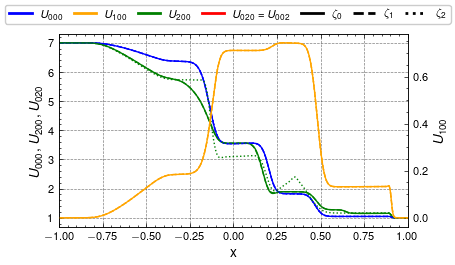

In [7]:
# Merging both
for Kn, source in zip(Knudsen, sources):
    fig, axs = plt.subplots(figsize=(6.0 * 3/4, 2.5))
    twx = axs.twinx()
    twx.grid(False)

    axs.set_xlim(-1, 1)
    axs.set_xlabel('x')
    axs.set_ylabel('$U_{000}$, $U_{200}, U_{020}$')
    twx.set_ylabel('$U_{100}$')

    # Stable angles
    for i in range(n_angle_pairs - 1):
        solution_file = name(i, Kn, source)
        data = read_solution_file(solution_file)
        
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))
        
        time_query = 21 
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, U = sol["x"], sol["u"]

        rho = U[:, 0]
        v = U[:, 1] / U[:, 0]
        theta = 1 / (3 * rho) * (U[:, 2] + 2 * U[:, 3] - rho * v**2) 
        p = rho * theta

        axs.plot(x, rho, color=colors[0], linestyle=linestyles[i])
        twx.plot(x, v, color=colors[1], linestyle=linestyles[i])
        axs.plot(x, p, color=colors[2], linestyle=linestyles[i])

        # axs.plot(x, U[:, 0], color=colors[0], linestyle=linestyles[i])
        # twx.plot(x, U[:, 1], color=colors[1], linestyle=linestyles[i])
        # axs.plot(x, U[:, 2], color=colors[2], linestyle=linestyles[i])
        # axs.plot(x, U[:, 3], color=colors[3], linestyle=linestyles[i])

    # * skip, as diverged
    # if source != 'zero_source': 
    #     # Window for unstable pair
    #     # Coordinates: [left, bottom, width, height] in figure fractions (0 to 1)
    #     inset_pos = [0.65, 0.58, 0.22, 0.28] 
    #     axs_inset = fig.add_axes(inset_pos)
    #     twx_inset = axs_inset.twinx()
    #     twx_inset.grid(False)

    #     # Style
    #     axs_inset.set_xlim(-1, 1)
    #     axs_inset.tick_params(axis='both', which='major', labelsize=8)
    #     twx_inset.tick_params(axis='both', which='major', labelsize=8)
    #     # axs_inset.set_title("Unstable Pair", fontsize=9, pad=2)

    #     # Plot unstable pair
    #     sol_last = interpolate_solution(read_solution_file(name(n_angle_pairs - 1, Kn, source)), 21, times, timesteps)
    #     x_l, U_l = sol_last["x"], sol_last["u"]

    #     axs_inset.plot(x_l, U_l[:, 0], color=colors[0])
    #     twx_inset.plot(x_l, U_l[:, 1], color=colors[1])

    # Legend and Layout
    elements = [
        Line2D([], [], color=colors[0], lw=2, label='$U_{000}$'),
        Line2D([], [], color=colors[1], lw=2, label='$U_{100}$'),
        Line2D([], [], color=colors[2], lw=2, label='$U_{200}$'),
        Line2D([], [], color=colors[3], lw=2, label='$U_{020}=U_{002}$'),
    ] + [Line2D([], [], color='black', linestyle=linestyles[i], lw=2, label=f'$\\zeta_{i}$') for i in range(n_angle_pairs-1)]

    fig.legend(
        handles=elements, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.02), # Increased to make room for the window
        ncol=7, 
        columnspacing=1.0 
    )

    # Note: tight_layout often crushes manual insets, so we use it carefully or skip it
    # fig.tight_layout() 
    fig.savefig(f'../out/Figures/1D3D/Merged_AnglePairs_Kn{Kn}_source_{source}.pdf', bbox_inches='tight')
    plt.show()

Eigenvalues: [-2.4494897427831597, -1.4491376746152853, -1.0000000000000215, -2.7171443922243594e-19, 1.3172655725758864e-18, 5.71114156372943e-17, 9.101525312757281e-17, 1.0000000000000213, 1.4491376746152862, 2.449489742783163]
Eigenvalues: [-2.44948974278316, -1.4491376746159763, -1.0000000000000215, -2.7171305457546744e-19, 5.423024045511925e-18, 7.349786603913225e-17, 1.0636691632653369e-16, 1.0000000000000207, 1.4491376746159768, 2.4494897427831672]
Eigenvalues: [-2.4494897313227475, -1.0036390780448092, -0.9999994660518067, -1.2888319015588943e-19, 8.719033986523488e-17, 1.2860913081723534e-16, 1.2860913081723534e-16, 0.9999994660518071, 1.0036390780448092, 2.4494897313227475]
Eigenvalues: [-2.4494908727414915, -0.9999997661467491, -1.6653345369377348e-16, -1.6653345369377348e-16, -2.3006231889766145e-17, -2.3006231889766145e-17, -2.4982161875310668e-18, 5.49965915804809e-17, 0.9999997661467481, 2.4494908727414995]
Eigenvalues: [-2.4494897427831615, -1.4491376746152846, -1.00000

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_99065/4087826162.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_99065/4087826162.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


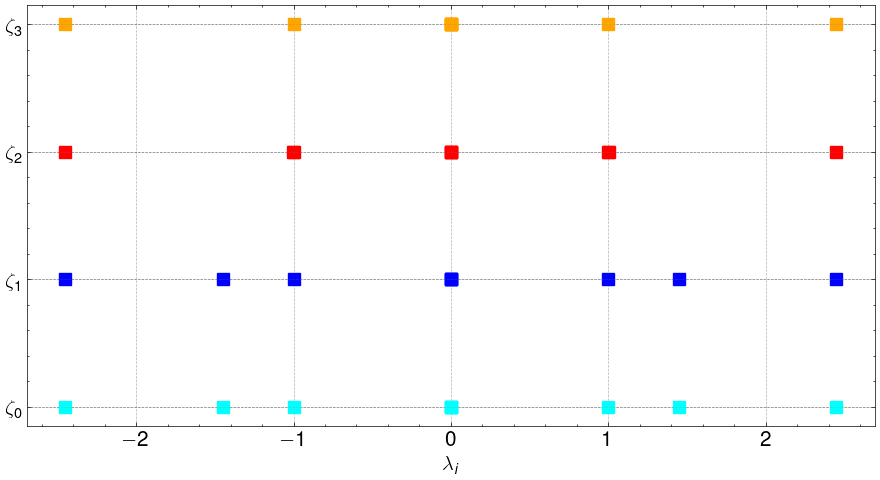

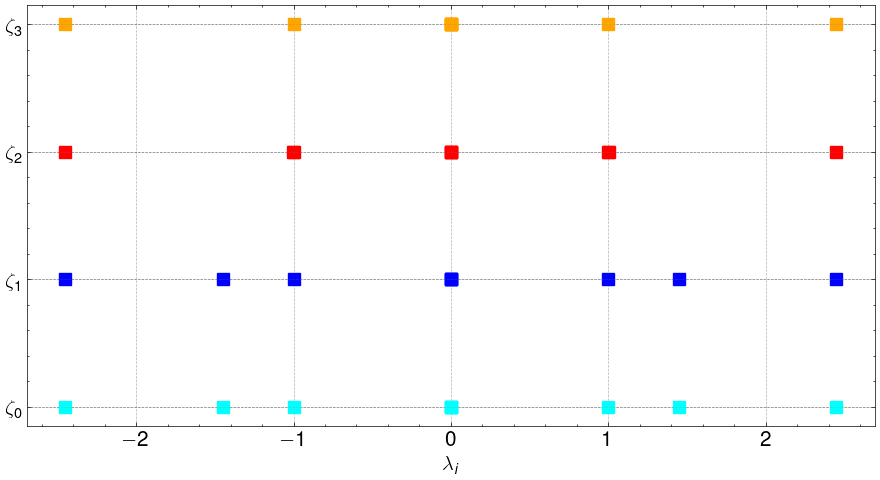

In [8]:
x_dest = -2.0

for Kn in [0.1, 1.0]:
    eigenvalues = []
    for anglepair in range(n_angle_pairs):
        file = lambda anglepairnumber: f'../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_eigenvalues.csv'
        data = pd.read_csv(file(anglepair))

        x_idx = (np.abs(data['x_vector'] - x_dest)).argmin()
        lambda_values_string = data['eigenvalue'][x_idx]
        lambda_values = [float(val) for val in lambda_values_string.strip('[]').split(',')]
        eigenvalues.append(lambda_values)

        print(f'Eigenvalues: {lambda_values}')

    angles = [
        (eigenvalues[0], 'cyan', '$\\zeta_0$'),
        (eigenvalues[1], 'blue', '$\\zeta_1$'),
        (eigenvalues[2], 'red', '$\\zeta_2$'),
        (eigenvalues[3], 'orange', '$\\zeta_3$')
    ]

    fig, axs = plt.subplots()

    for i, (lambda_values, color, label) in enumerate(angles):
        # Plot the eigenvalues as points at height 'i'
        axs.plot(lambda_values, [i] * len(lambda_values), 's', color=color, markersize=8, label=label)
        
        # Add a faint horizontal line to guide the eye for each category
        axs.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

    axs.tick_params(axis='x', labelsize=15)
    axs.set_yticks(range(len(angles)), [m[2] for m in angles], fontsize=15)

    axs.set_xlabel('$\\lambda_i$', fontsize=15)
    # axs.set_ylabel('Closure Model')
    axs.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

    fig.tight_layout()
    # fig.savefig('../out/Figures/1D3D/Eigenvalues_Equilibrium.pdf')
    fig.show()

Eigenvalues: [-2.236201519171144, -1.2073440023602153, -0.7694475989040291, 0.21082209300526955, 0.2166168189215244, 0.2166168189215244, 0.24333294286749163, 1.1321647671302228, 1.5818245045336228, 2.5369446352508125]
Eigenvalues: [-2.2361418368375143, -1.2084292477260337, -0.7694227782493537, 0.21674830774642828, 0.21872121578967907, 0.21872121578967907, 0.24333816932700847, 1.1321900290410196, 1.5817080685000466, 2.5369548539567326]
Eigenvalues: [-2.239198424548727, -0.7944212829314379, -0.7704091588949897, 0.23021608242171335, 0.23549877895738602, 0.23549877895738602, 0.2419455918379848, 1.1280770300276346, 1.1601430914845035, 2.5337549955835117]
Eigenvalues: [-2.2877287557045656, -0.7661342120295582, -0.56150278294948, 0.22837642946965456, 0.2550689888686405, 0.36002070848233686, 0.9917074138567745, 0.9917074138567745, 1.0066081183636473, 2.7088597736824602]
Eigenvalues: [-2.2681820312042973, -0.9540307872345508, -0.5348107541996868, 0.4554885180141355, 0.47359323988715496, 0.47359

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_99065/3279054937.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_99065/3279054937.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


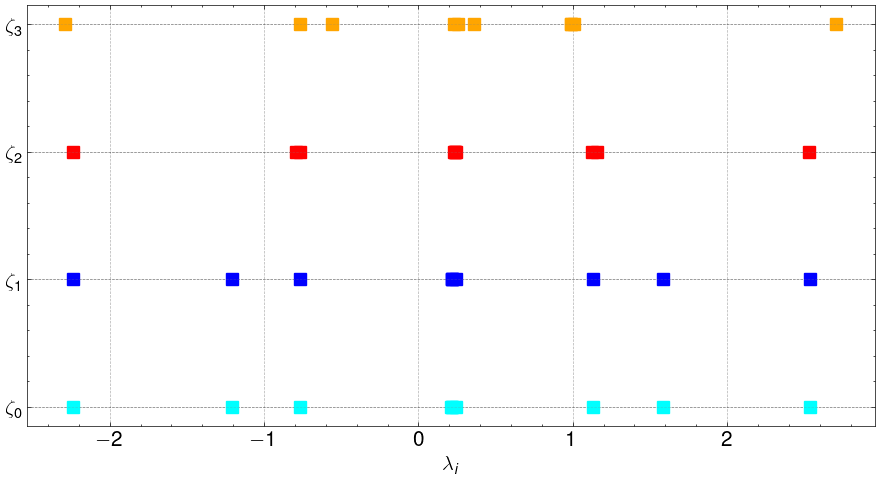

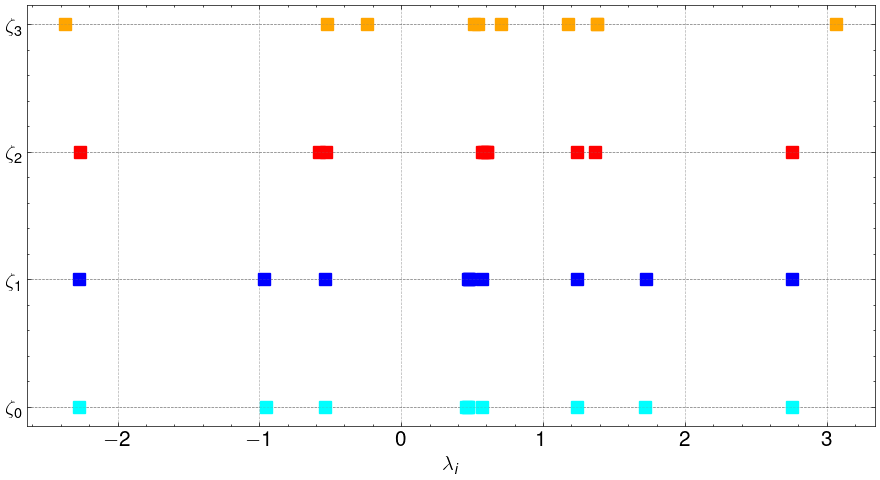

In [9]:
x_dest = 0.0

for Kn in [0.1, 1.0]:
    eigenvalues = []
    for anglepair in range(n_angle_pairs):
        file = lambda anglepairnumber: f'../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_eigenvalues.csv'
        data = pd.read_csv(file(anglepair))

        x_idx = (np.abs(data['x_vector'] - x_dest)).argmin()
        lambda_values_string = data['eigenvalue'][x_idx]
        lambda_values = [float(val) for val in lambda_values_string.strip('[]').split(',')]
        eigenvalues.append(lambda_values)

        print(f'Eigenvalues: {lambda_values}')

    angles = [
        (eigenvalues[0], 'cyan', '$\\zeta_0$'),
        (eigenvalues[1], 'blue', '$\\zeta_1$'),
        (eigenvalues[2], 'red', '$\\zeta_2$'),
        (eigenvalues[3], 'orange', '$\\zeta_3$')
    ]

    fig, axs = plt.subplots()

    for i, (lambda_values, color, label) in enumerate(angles):
        # Plot the eigenvalues as points at height 'i'
        axs.plot(lambda_values, [i] * len(lambda_values), 's', color=color, markersize=8, label=label)
        
        # Add a faint horizontal line to guide the eye for each category
        axs.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

    axs.tick_params(axis='x', labelsize=15)
    axs.set_yticks(range(len(angles)), [m[2] for m in angles], fontsize=15)

    axs.set_xlabel('$\\lambda_i$', fontsize=15)
    # axs.set_ylabel('Closure Model')
    axs.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

    fig.tight_layout()
    # fig.savefig('../out/Figures/1D3D/Eigenvalues_Shock.pdf')
    fig.show()

# Check stabilization for Grad

In [10]:
closure = "Grad"
Kn = 1.0
source = "relaxation_source"

# Initial condition parameters for the Riemann problem
rho_L_vec = [4.0, 7.0, 15.0] #! 30.0 unstable for 1D1D and 1D3D
v_L1 = 0.0
v_L2 = 0.0
v_L3 = 0.0
theta_L = 1.0
rho_R = 1.0
v_R1 = 0.0
v_R2 = 0.0
v_R3 = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

FileNotFoundError: [Errno 2] No such file or directory: '../out/1D3D/Moments/gram_solution_M4_closureGrad_Kn1.0_sourcerelaxation_source_T_end0.3_rho_L4.0_rho_R1.0_v_L10.0_v_L20.0_v_L30.0_v_R10.0_v_R20.0_v_R30.0_theta_L1.0_theta_R1.0_base_tree_level10_polydeg1_cons.tsv'

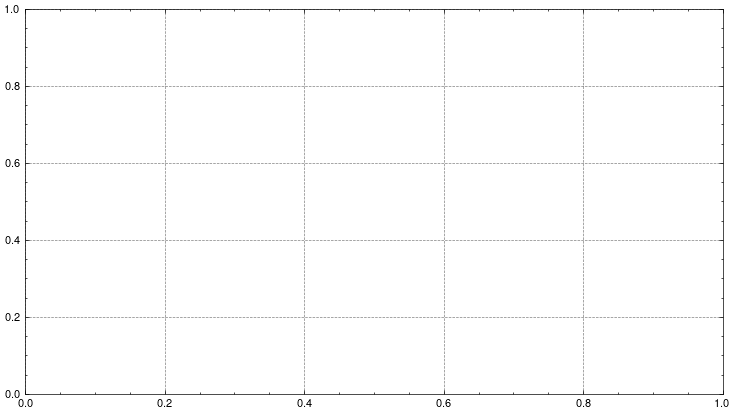

In [15]:
fig, axs = plt.subplots()

name1D3D = lambda rho_L: f"../out/1D3D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
name1D1D = lambda rho_L: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L1}_v_R{v_R1}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

for rho_L in rho_L_vec:
    data_1D3D = read_solution_file(name1D3D(rho_L))
    data_1D1D = read_solution_file(name1D1D(rho_L))

    times_1D3D = np.array([data_1D3D[ts]["t"] for ts in sorted(data_1D3D.keys())])
    timesteps_1D3D = np.array(sorted(data_1D3D.keys()))

    times_1D1D = np.array([data_1D1D[ts]["t"] for ts in sorted(data_1D1D.keys())])
    timesteps_1D1D = np.array(sorted(data_1D1D.keys()))

    time_query = 21 
    sol_1D3D = interpolate_solution(data_1D3D, time_query, times_1D3D, timesteps_1D3D)
    sol_1D1D = interpolate_solution(data_1D1D, time_query, times_1D1D, timesteps_1D1D)

    x_3d, U_3d = sol_1D3D["x"], sol_1D3D["u"]
    x_2d, U_2d = sol_1D1D["x"], sol_1D1D["u"]

    axs.plot(x_3d, U_3d[:, 0], color='blue', linestyle='-', label=f'Riemann 3Dx3V, $\\rho_L={rho_L}$')
    axs.plot(x_2d, U_2d[:, 0], color='red', linestyle='--', label=f'Riemann 2Dx2V, $\\rho_L={rho_L}$')